In [2]:
# Step 1:Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import keras
import tensorflow as tf
import plotly.express as px


In [3]:
pd.options.display.max_rows=10

In [4]:
pd.options.display.float_format="{:.1f}".format

In [9]:
data=pd.read_excel("C:\\Users\\User\\OneDrive\\Desktop\\Rice_Cammeo_Osmancik.xlsx")

In [10]:
print(data)

       Area  Perimeter  Major_Axis_Length  Minor_Axis_Length  Eccentricity  \
0     15231      525.6              229.7               85.1           0.9   
1     14656      494.3              206.0               91.7           0.9   
2     14634      501.1              214.1               87.8           0.9   
3     13176      458.3              193.3               87.4           0.9   
4     14688      507.2              211.7               89.3           0.9   
...     ...        ...                ...                ...           ...   
3805  11441      415.9              170.5               85.8           0.9   
3806  11625      421.4              167.7               89.5           0.8   
3807  12437      442.5              183.6               86.8           0.9   
3808   9882      392.3              161.2               78.2           0.9   
3809  11434      404.7              161.1               90.9           0.8   

      Convex_Area  Extent     Class  
0           15617     0.6

In [12]:
rice_dataset=data[[
    "Area",
    "Perimeter",
    "Major_Axis_Length",
    "Minor_Axis_Length",
    "Eccentricity",
    "Convex_Area",
    "Extent",
    "Class"
]]

In [13]:
print(rice_dataset)

       Area  Perimeter  Major_Axis_Length  Minor_Axis_Length  Eccentricity  \
0     15231      525.6              229.7               85.1           0.9   
1     14656      494.3              206.0               91.7           0.9   
2     14634      501.1              214.1               87.8           0.9   
3     13176      458.3              193.3               87.4           0.9   
4     14688      507.2              211.7               89.3           0.9   
...     ...        ...                ...                ...           ...   
3805  11441      415.9              170.5               85.8           0.9   
3806  11625      421.4              167.7               89.5           0.8   
3807  12437      442.5              183.6               86.8           0.9   
3808   9882      392.3              161.2               78.2           0.9   
3809  11434      404.7              161.1               90.9           0.8   

      Convex_Area  Extent     Class  
0           15617     0.6

In [14]:
rice_dataset.describe()

,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent
count,3810.0,3810.0,3810.0,3810.0,3810.0,3810.0,3810.0
mean,12667.7,454.2,188.8,86.3,0.9,12952.5,0.7
std,1732.4,35.6,17.4,5.7,0.0,1777.0,0.1
min,7551.0,359.1,145.3,59.5,0.8,7723.0,0.5
25%,11370.5,426.1,174.4,82.7,0.9,11626.2,0.6
50%,12421.5,448.9,185.8,86.4,0.9,12706.5,0.6
75%,13950.0,483.7,203.6,90.1,0.9,14284.0,0.7
max,18913.0,548.4,239.0,107.5,0.9,19099.0,0.9


In [15]:
# Major_Axis_Length
# min:145.3
# max:239.0
# Area
# min:7551
# max:18913.0
# Perimeter
# 35.6

rangeofArea=18913-7551
print(rangeofArea)
stdfromMean=454.2-35.6
print(stdfromMean)


11362
418.59999999999997


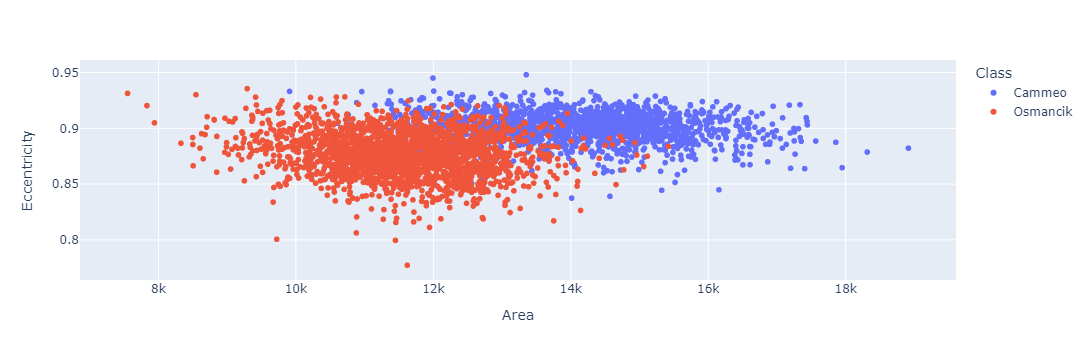

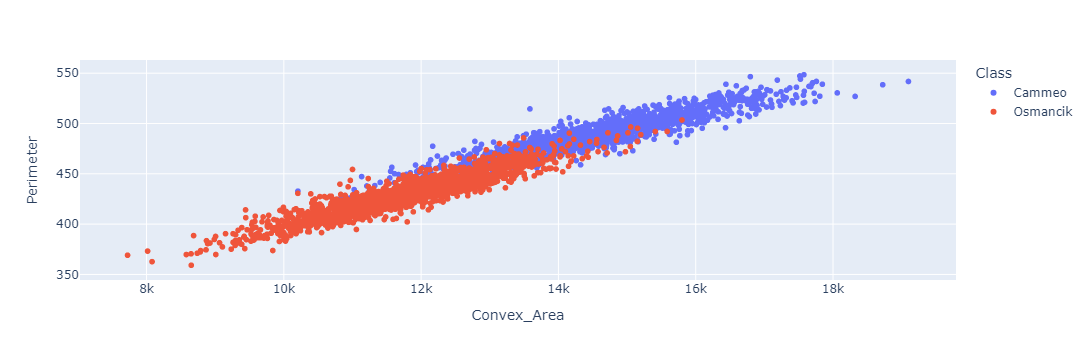

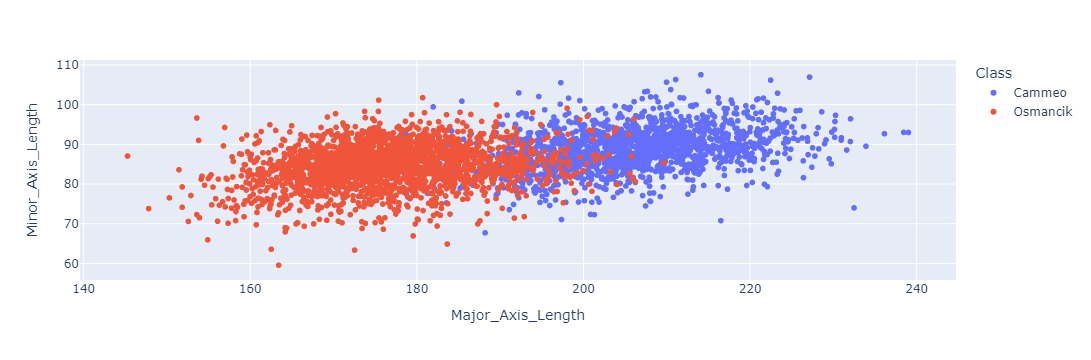

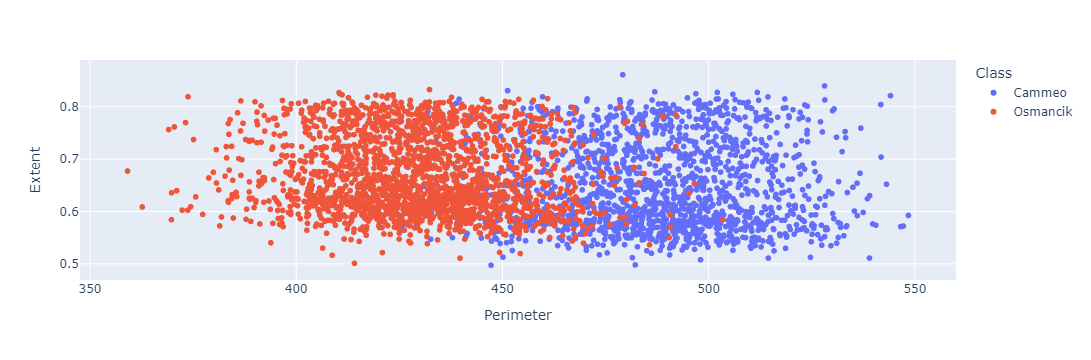

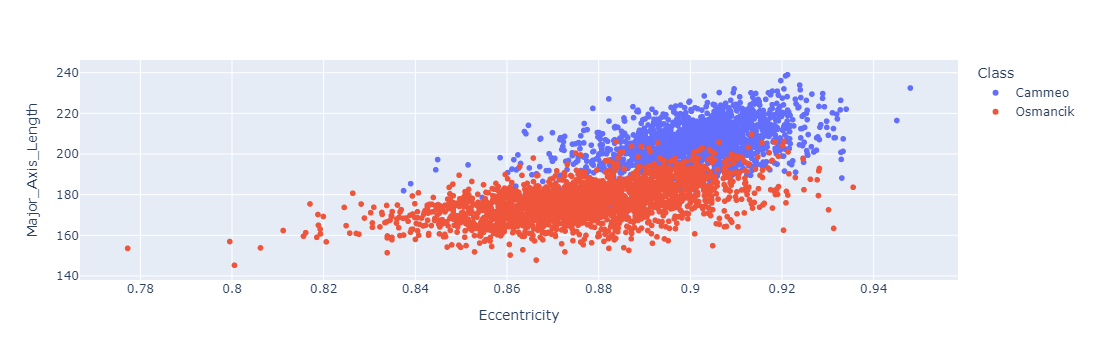

In [16]:
for x_axis_data, y_axis_data in [
    ('Area', 'Eccentricity'),
    ('Convex_Area', 'Perimeter'),
    ('Major_Axis_Length', 'Minor_Axis_Length'),
    ('Perimeter', 'Extent'),
    ('Eccentricity', 'Major_Axis_Length'),
]:
  px.scatter(rice_dataset, x=x_axis_data, y=y_axis_data, color='Class').show()

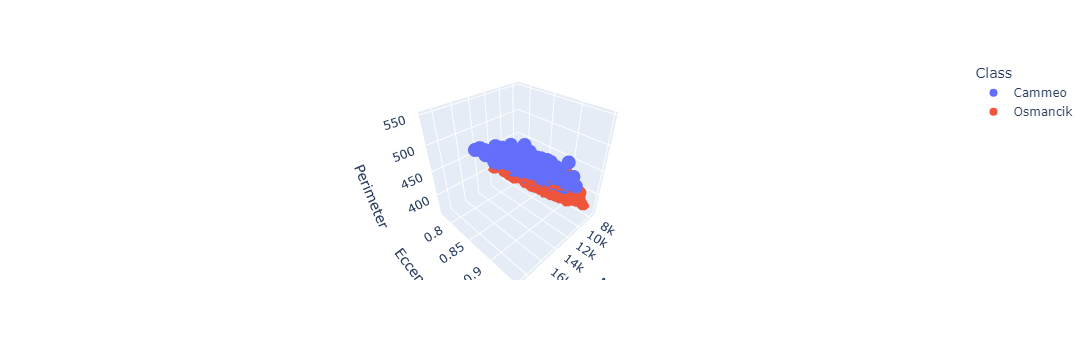

In [19]:
for x_axis_data, y_axis_data,z_axis_data in [
    ('Area', 'Eccentricity','Perimeter')
]:
  px.scatter_3d(rice_dataset, x=x_axis_data, y=y_axis_data,z=z_axis_data, color='Class').show()

In [21]:
feature_mean=rice_dataset.mean(numeric_only=True)
feature_std=rice_dataset.std(numeric_only=True)
print(feature_mean)
print(feature_std)

Area                12667.7
Perimeter             454.2
Major_Axis_Length     188.8
Minor_Axis_Length      86.3
Eccentricity            0.9
Convex_Area         12952.5
Extent                  0.7
dtype: float64
Area                1732.4
Perimeter             35.6
Major_Axis_Length     17.4
Minor_Axis_Length      5.7
Eccentricity           0.0
Convex_Area         1777.0
Extent                 0.1
dtype: float64


In [22]:
numerical_features = rice_dataset.select_dtypes('number').columns

In [23]:
normalized_dataset = (
    rice_dataset[numerical_features] - feature_mean
) / feature_std

In [24]:
print(normalized_dataset)

      Area  Perimeter  Major_Axis_Length  Minor_Axis_Length  Eccentricity  \
0      1.5        2.0                2.3               -0.2           2.0   
1      1.1        1.1                1.0                0.9           0.4   
2      1.1        1.3                1.5                0.3           1.2   
3      0.3        0.1                0.3                0.2           0.2   
4      1.2        1.5                1.3                0.5           1.0   
...    ...        ...                ...                ...           ...   
3805  -0.7       -1.1               -1.0               -0.1          -1.1   
3806  -0.6       -0.9               -1.2                0.5          -2.0   
3807  -0.1       -0.3               -0.3                0.1          -0.3   
3808  -1.6       -1.7               -1.6               -1.4          -0.6   
3809  -0.7       -1.4               -1.6                0.8          -2.9   

      Convex_Area  Extent  
0             1.5    -1.2  
1             1.2  

In [25]:
normalized_dataset['Class'] = rice_dataset['Class']

In [26]:
normalized_dataset.head()

,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent,Class
0,1.5,2.0,2.3,-0.2,2.0,1.5,-1.2,Cammeo
1,1.1,1.1,1.0,0.9,0.4,1.2,-0.6,Cammeo
2,1.1,1.3,1.5,0.3,1.2,1.1,0.4,Cammeo
3,0.3,0.1,0.3,0.2,0.2,0.2,-0.3,Cammeo
4,1.2,1.5,1.3,0.5,1.0,1.3,-0.2,Cammeo


In [27]:
keras.utils.set_random_seed(42)

In [28]:
normalized_dataset['Class_Bool'] = (
    # Returns true if class is Cammeo, and false if class is Osmancik
    normalized_dataset['Class'] == 'Cammeo'
).astype(int)
normalized_dataset.sample(10)

,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent,Class,Class_Bool
1011,-0.1,0.1,-0.1,0.2,-0.1,-0.0,-1.0,Cammeo,1
3185,-0.1,-0.5,-0.5,0.4,-0.8,-0.2,-0.3,Osmancik,0
3698,0.1,-0.1,-0.4,0.9,-1.1,0.1,-0.2,Osmancik,0
897,0.2,0.5,0.8,-0.5,1.2,0.2,1.5,Cammeo,1
3245,-1.3,-1.3,-0.9,-1.6,0.5,-1.4,-1.1,Osmancik,0
478,0.2,0.2,0.4,-0.0,0.5,0.2,1.7,Cammeo,1
1731,-0.4,-0.8,-0.8,0.3,-1.0,-0.5,-0.4,Osmancik,0
1025,0.6,0.7,0.6,0.3,0.5,0.6,-0.5,Cammeo,1
429,1.2,1.2,1.4,0.6,1.0,1.2,1.8,Cammeo,1
1330,-0.4,-0.0,0.4,-1.3,1.4,-0.5,-0.1,Cammeo,1


In [29]:
number_samples = len(normalized_dataset)
print(number_samples)

3810


In [32]:
index_80th=round(number_samples*0.8)
print(index_80th)

3048


In [33]:
index_90th=index_80th+round(number_samples*0.1)

In [34]:
print(index_90th)

3429


In [35]:
shuffled_dataset = normalized_dataset.sample(frac=1, random_state=100)

In [36]:
train_data = shuffled_dataset.iloc[0:index_80th]

In [37]:
validation_data = shuffled_dataset.iloc[index_80th:index_90th]

In [38]:
test_data = shuffled_dataset.iloc[index_90th:]

In [39]:
print(test_data.head())

      Area  Perimeter  Major_Axis_Length  Minor_Axis_Length  Eccentricity  \
2405  -0.4       -0.7               -0.8                0.3          -1.1   
3062  -0.2       -0.0                0.2               -0.7           0.8   
1155   1.4        1.2                1.1                1.2           0.3   
660    1.2        1.0                0.8                1.3          -0.0   
2451  -1.2       -1.2               -1.4               -0.3          -1.5   

      Convex_Area  Extent     Class  Class_Bool  
2405         -0.4     0.3  Osmancik           0  
3062         -0.2     1.6  Osmancik           0  
1155          1.3     0.7    Cammeo           1  
660           1.2    -0.6    Cammeo           1  
2451         -1.1     0.1  Osmancik           0  


In [40]:
label_columns = ['Class', 'Class_Bool']

In [41]:
train_features = train_data.drop(columns=label_columns)

In [42]:
train_labels = train_data['Class_Bool'].to_numpy()

In [43]:
validation_features = validation_data.drop(columns=label_columns)

In [44]:
validation_labels=validation_data['Class_Bool'].to_numpy()

In [45]:
test_features=test_data.drop(columns=label_columns)

In [46]:
test_labels=test_data['Class_Bool'].to_numpy()

In [47]:
input_features = [
    'Eccentricity',
    'Major_Axis_Length',
    'Area',
]

In [49]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score

# Load dataset
df = pd.read_excel("C:\\Users\\User\\OneDrive\\Desktop\\Rice_Cammeo_Osmancik.xlsx")

X = df.drop("Class", axis=1)
y = df["Class"]

# Encode labels (Osmancik=0, Cammeo=1 for example)
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Build Neural Network
model = keras.Sequential([
    keras.layers.Dense(32, activation="relu", input_shape=(X_train.shape[1],)),
    keras.layers.Dense(16, activation="relu"),
    keras.layers.Dense(1, activation="sigmoid")   # Binary classification
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.1)

# Evaluate
loss, acc = model.evaluate(X_test, y_test)
print("\nTest Accuracy:", acc)

# Predict
sample = np.array([X_test[1]])
pred = model.predict(sample)
print("\nPredicted class:", (pred > 0.5).astype(int))


Epoch 1/20


C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8917 - loss: 0.3871 - val_accuracy: 0.8820 - val_loss: 0.2684
Epoch 2/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9227 - loss: 0.2069 - val_accuracy: 0.8984 - val_loss: 0.2179
Epoch 3/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9289 - loss: 0.1908 - val_accuracy: 0.9016 - val_loss: 0.2091
Epoch 4/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9300 - loss: 0.1877 - val_accuracy: 0.9016 - val_loss: 0.2058
Epoch 5/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9315 - loss: 0.1862 - val_accuracy: 0.9016 - val_loss: 0.2045
Epoch 6/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9318 - loss: 0.1852 - val_accuracy: 0.9016 - val_loss: 0.2036
Epoch 7/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9318 - loss: 0.1845 - val_accuracy: 0.8984 - val_loss: 0.2029
Epoch 8/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9315 - loss: 0.1839 - val_accuracy: 0.8984 - val_loss: 0.2026
Ep